# Algoritmo de ruta y optimizacion greedy con restricciones

Este notebook desarrolla la siguiente fase prevista en el Gantt del TFM:

- Crear un algoritmo de ruta y su optimizacion
- Mantener una logica explicable y reutilizable
- Preparar la futura integracion con el sistema hibrido final

La idea no es construir una optimizacion compleja tipo TSP con coste elevado, sino una solucion tecnica razonable para el estado actual del proyecto:

- usar `score` como senal principal de ranking
- permitir integrar `similarity_score` cuando los candidatos vengan del recomendador TF-IDF
- aprovechar `cluster_geo` como ayuda para mantener coherencia espacial
- respetar restricciones de distancia, numero de POIs y tiempo disponible
- evitar saltos geograficos absurdos con una restriccion sobre la distancia por tramo

Por tanto, este bloque ya forma parte del **nucleo operativo del sistema hibrido**, aunque todavia no es la integracion final completa de todos los modulos.

In [3]:
# ==============================
# 1. Carga de librerias
# ==============================

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Configuracion visual basica para tablas y graficos.
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 5)


In [4]:
# ==============================
# 2. Carga de datos
# ==============================

# Construimos una ruta robusta al dataset para que el notebook funcione
# tanto si se ejecuta desde la carpeta modelo como desde la raiz del proyecto.
possible_paths = [
    Path('../data/pois_barcelona_procesados.parquet'),
    Path('data/pois_barcelona_procesados.parquet')
]
data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError('No se encontro el parquet de entrada para el notebook de rutas.')

# Cargamos el parquet procesado porque es el formato usado en el resto de notebooks.
df = pd.read_parquet(data_path)

# Seleccionamos solo las columnas utiles para la fase de ruta.
# cluster_geo se considera opcional porque puede existir en el notebook de clustering
# sin haberse persistido todavia en el parquet final.
columnas_base_ruta = [
    'id',
    'name',
    'category',
    'subcategory',
    'latitude',
    'longitude',
    'rating',
    'score',
    'visit_duration'
]

columnas_existentes = [col for col in columnas_base_ruta if col in df.columns]
df_route = df[columnas_existentes].copy()

# Si cluster_geo no esta persistido, lo dejamos como columna vacia.
if 'cluster_geo' in df.columns:
    df_route['cluster_geo'] = df['cluster_geo']
else:
    df_route['cluster_geo'] = np.nan
    print("Aviso: la columna 'cluster_geo' no existe en el parquet actual. Se tratara como senal opcional no disponible en esta ejecucion.")

# Dejamos preparada una columna opcional para integrar mas adelante la similitud
# del recomendador basado en contenido. Si todavia no existe, usamos una senal neutra.
if 'similarity_score' not in df_route.columns:
    df_route['similarity_score'] = np.nan

# Eliminamos POIs sin coordenadas porque no podrian entrar en ninguna ruta valida.
df_route = df_route.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

print('Shape del dataset para rutas:', df_route.shape)
display(df_route.head())


Aviso: la columna 'cluster_geo' no existe en el parquet actual. Se tratara como senal opcional no disponible en esta ejecucion.
Shape del dataset para rutas: (774, 11)


,id,name,category,subcategory,latitude,longitude,rating,score,visit_duration,cluster_geo,similarity_score
0,3,Biblioteca de Cataluña,cultural,library,41.3810,2.16951,4.2,3.21900,60,NaN,NaN
1,34,Esquerra de l'Eixample,cultural,library,41.3868,2.15205,4.1,2.56796,60,NaN,NaN
2,35,Can Mariner (Barcelona),cultural,library,41.4312,2.16056,4.1,3.06500,60,NaN,NaN
3,111,Archivo Histórico de la Ciudad de Barcelona,cultural,library,41.3841,2.17567,4.3,2.68696,60,NaN,NaN
4,112,Arxiu Diocesà de Barcelona,cultural,library,41.3837,2.17534,4.2,3.16500,60,NaN,NaN


## 3. Revision de variables utiles para la ruta

En esta fase nos interesan especialmente estas senales:

- `score`: ranking principal ya validado en el notebook de ranking adicional
- `similarity_score`: senal opcional para el futuro sistema hibrido cuando los candidatos vengan del recomendador TF-IDF
- `cluster_geo`: ayuda para evitar recorridos poco coherentes espacialmente
- `visit_duration`: permite incorporar una restriccion de tiempo total
- `category` y `subcategory`: permiten respetar preferencias del usuario
- `latitude` y `longitude`: necesarias para calcular distancias y construir la ruta

La ruta no debe interpretar todos los modulos como si tuvieran el mismo papel:

- TF-IDF ayuda a seleccionar **candidatos semanticamente relevantes**
- `score` ayuda a priorizar **calidad/relevancia**
- `cluster_geo` ayuda a mantener **coherencia espacial**
- el algoritmo greedy decide el **orden secuencial de visita bajo restricciones**

In [5]:
# ==============================
# 3. Revision rapida de variables
# ==============================

print('Columnas disponibles para la ruta:')
print(df_route.columns.tolist())

print('\nValores nulos en variables clave:')
display(df_route[['rating', 'score', 'visit_duration', 'cluster_geo', 'similarity_score']].isna().sum().to_frame('nulos'))

print('\nCategorias mas frecuentes:')
display(df_route['category'].value_counts().head(10).to_frame('n_pois'))

print('\nSubcategorias mas frecuentes:')
display(df_route['subcategory'].value_counts().head(10).to_frame('n_pois'))


Columnas disponibles para la ruta:
['id', 'name', 'category', 'subcategory', 'latitude', 'longitude', 'rating', 'score', 'visit_duration', 'cluster_geo', 'similarity_score']

Valores nulos en variables clave:


,nulos
rating,0
score,0
visit_duration,0
cluster_geo,774
similarity_score,774



Categorias mas frecuentes:


,n_pois
category,
cultural,331
monument,100
tourist_attraction,84
fountain,75
park,61
religious,44
historic,41
administrative,35
bridge,3



Subcategorias mas frecuentes:


,n_pois
subcategory,
library,94
museum,90
attraction,84
fountain,75
monument,72
artwork,65
conservatory,61
theatre,45
church,38


## 4. Definicion de restricciones y senales

La estrategia elegida sera un **greedy con restricciones y score compuesto**.

En cada iteracion el algoritmo evaluara los POIs restantes y elegira el siguiente que maximice una utilidad compuesta, siempre que cumpla:

- distancia total maxima
- numero maximo de POIs
- tiempo total disponible
- distancia maxima por tramo para evitar saltos grandes

La utilidad combinara varias senales:

- calidad global del POI via `score`
- similitud semantica opcional via `similarity_score`
- cercania respecto al punto actual de la ruta
- penalizacion por alejarse demasiado del origen
- bonus por coherencia de cluster cuando sea util
- ligera penalizacion por duraciones excesivas si el tiempo es limitado

Este enfoque es adecuado para el TFM porque:

- es interpretable
- se integra bien con los modulos ya creados
- puede trasladarse luego al backend sin cambiar la logica de negocio
- deja espacio para una futura optimizacion mas avanzada si realmente aporta valor

In [6]:
# ==============================
# 4. Funciones auxiliares
# ==============================

def haversine_km(lat1, lon1, lat2, lon2):
    # Distancia geodesica aproximada en km entre dos coordenadas.
    r = 6371.0

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )

    return 2 * r * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def min_max_normalize(series, fill_value=0.0):
    # Normalizacion robusta para combinar senales heterogeneas.
    data = pd.Series(series, copy=True)

    if data.notna().sum() == 0:
        return pd.Series(fill_value, index=data.index, dtype=float)

    min_value = data.min(skipna=True)
    max_value = data.max(skipna=True)

    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(fill_value, index=data.index, dtype=float)

    normalized = (data - min_value) / (max_value - min_value)
    return normalized.fillna(fill_value)


def preparar_candidatos_para_ruta(df_input, preferences):
    # Partimos de una copia para no tocar el dataframe original.
    data = df_input.copy()

    # Normalizamos listas de filtros del usuario.
    categorias = preferences.get('categories') or []
    subcategorias = preferences.get('subcategories') or []
    categorias = [c for c in categorias if c is not None]
    subcategorias = [s for s in subcategorias if s is not None]

    # Aplicamos filtros por categoria y subcategoria si existen.
    if categorias:
        data = data[data['category'].isin(categorias)]

    if subcategorias:
        data = data[data['subcategory'].isin(subcategorias)]

    # Filtramos por rating minimo cuando tenga sentido.
    min_rating = preferences.get('min_rating', 0)
    data = data[data['rating'].fillna(0) >= min_rating]

    start_lat = preferences['start_lat']
    start_lon = preferences['start_lon']

    # Calculamos la distancia desde el punto inicial para controlar viabilidad.
    data['distance_from_start_km'] = data.apply(
        lambda row: haversine_km(start_lat, start_lon, row['latitude'], row['longitude']),
        axis=1
    )

    # Si un POI ya esta mas lejos del presupuesto total de distancia,
    # no tiene sentido considerarlo desde el inicio.
    max_distance_km = preferences.get('max_distance_km', 6)
    data = data[data['distance_from_start_km'] <= max_distance_km].copy()

    # Imputaciones sencillas y consistentes con el estado actual del proyecto.
    data['visit_duration'] = data['visit_duration'].fillna(preferences.get('default_visit_duration', 45))
    data['score'] = data['score'].fillna(data['rating']).fillna(0)
    data['similarity_score'] = data['similarity_score'].fillna(preferences.get('default_similarity_score', 0.0))

    return data.reset_index(drop=True)


In [7]:
# ==============================
# 5. Diseno del score del siguiente POI
# ==============================

def scorear_siguientes_pois(candidates, current_point, start_point, current_cluster, preferences):
    # Calculamos la distancia desde el punto actual de la ruta hasta cada candidato.
    scored = candidates.copy()
    scored['distance_from_current_km'] = scored.apply(
        lambda row: haversine_km(
            current_point['lat'],
            current_point['lon'],
            row['latitude'],
            row['longitude']
        ),
        axis=1
    )

    # Distancia de retorno al origen si se visitara ese POI.
    scored['return_to_start_km'] = scored.apply(
        lambda row: haversine_km(
            row['latitude'],
            row['longitude'],
            start_point['lat'],
            start_point['lon']
        ),
        axis=1
    )

    # Senales normalizadas para mezclar ranking, proximidad y tiempo.
    scored['score_norm'] = min_max_normalize(scored['score'], fill_value=0.0)
    scored['similarity_norm'] = min_max_normalize(scored['similarity_score'], fill_value=0.0)
    scored['proximity_norm'] = 1 - min_max_normalize(scored['distance_from_current_km'], fill_value=0.0)
    scored['start_distance_penalty'] = min_max_normalize(scored['distance_from_start_km'], fill_value=0.0)
    scored['duration_penalty'] = min_max_normalize(scored['visit_duration'], fill_value=0.0)

    # Bonus binario para premiar continuidad espacial cuando se use cluster_geo.
    use_cluster = preferences.get('use_cluster_coherence', True)
    if use_cluster and current_cluster is not None:
        scored['cluster_bonus'] = (scored['cluster_geo'] == current_cluster).astype(float)
    else:
        scored['cluster_bonus'] = 0.0

    weights = preferences.get('weights', {
        'ranking': 0.40,
        'similarity': 0.20,
        'proximity': 0.25,
        'cluster': 0.10,
        'duration_penalty': 0.03,
        'distance_penalty': 0.02,
    })

    # Utilidad explicable para decidir el siguiente POI.
    scored['greedy_utility'] = (
        weights['ranking'] * scored['score_norm']
        + weights['similarity'] * scored['similarity_norm']
        + weights['proximity'] * scored['proximity_norm']
        + weights['cluster'] * scored['cluster_bonus']
        - weights['duration_penalty'] * scored['duration_penalty']
        - weights['distance_penalty'] * scored['start_distance_penalty']
    )

    return scored.sort_values('greedy_utility', ascending=False)


In [8]:
# ==============================
# 6. Implementacion del algoritmo de ruta
# ==============================

def construir_ruta_greedy(df_input, preferences):
    # Filtramos y preparamos los candidatos iniciales.
    candidates = preparar_candidatos_para_ruta(df_input, preferences)

    start_point = {
        'lat': preferences['start_lat'],
        'lon': preferences['start_lon']
    }

    current_point = start_point.copy()
    current_cluster = None

    route_rows = []
    total_distance_km = 0.0
    total_visit_minutes = 0.0

    max_pois = preferences.get('max_pois', 6)
    max_distance_km = preferences.get('max_distance_km', 6)
    max_time_minutes = preferences.get('max_time_minutes', 240)
    max_leg_distance_km = preferences.get('max_leg_distance_km', 2.5)

    while len(route_rows) < max_pois and not candidates.empty:
        ranked = scorear_siguientes_pois(
            candidates=candidates,
            current_point=current_point,
            start_point=start_point,
            current_cluster=current_cluster,
            preferences=preferences
        )

        next_poi = None

        # Recorremos de mejor a peor utilidad hasta encontrar un candidato viable.
        for _, candidate in ranked.iterrows():
            leg_distance_km = candidate['distance_from_current_km']
            return_distance_km = candidate['return_to_start_km']
            visit_minutes = candidate['visit_duration']

            projected_distance_km = total_distance_km + leg_distance_km + return_distance_km
            projected_time_minutes = total_visit_minutes + visit_minutes

            # Esta restriccion evita saltos grandes entre POIs consecutivos.
            if leg_distance_km > max_leg_distance_km:
                continue

            # Forzamos viabilidad global teniendo en cuenta el retorno al origen.
            if projected_distance_km > max_distance_km:
                continue

            if projected_time_minutes > max_time_minutes:
                continue

            next_poi = candidate.copy()
            break

        # Si ya no queda ningun candidato viable, terminamos la ruta.
        if next_poi is None:
            break

        total_distance_km += next_poi['distance_from_current_km']
        total_visit_minutes += next_poi['visit_duration']

        next_poi['route_position'] = len(route_rows) + 1
        next_poi['distance_from_previous_km'] = next_poi['distance_from_current_km']
        next_poi['distance_accumulated_km'] = total_distance_km
        next_poi['time_accumulated_min'] = total_visit_minutes

        route_rows.append(next_poi)

        current_point = {
            'lat': next_poi['latitude'],
            'lon': next_poi['longitude']
        }
        current_cluster = next_poi['cluster_geo']

        # Eliminamos el POI ya visitado para evitar repeticiones.
        candidates = candidates[candidates['id'] != next_poi['id']].copy()

    route_df = pd.DataFrame(route_rows)

    if route_df.empty:
        return route_df, {
            'total_pois': 0,
            'total_distance_km': 0.0,
            'return_to_start_km': 0.0,
            'total_route_distance_km': 0.0,
            'total_visit_minutes': 0.0,
            'average_score': 0.0,
            'average_similarity_score': 0.0
        }

    # Calculamos la distancia de regreso al origen para tener una metrica completa.
    return_to_start_km = haversine_km(
        current_point['lat'],
        current_point['lon'],
        start_point['lat'],
        start_point['lon']
    )

    summary = {
        'total_pois': int(len(route_df)),
        'total_distance_km': round(float(route_df['distance_from_previous_km'].sum()), 2),
        'return_to_start_km': round(float(return_to_start_km), 2),
        'total_route_distance_km': round(float(route_df['distance_from_previous_km'].sum() + return_to_start_km), 2),
        'total_visit_minutes': round(float(route_df['visit_duration'].sum()), 1),
        'average_score': round(float(route_df['score'].mean()), 3),
        'average_similarity_score': round(float(route_df['similarity_score'].mean()), 3)
    }

    return route_df, summary


In [9]:
# ==============================
# 7. Calculo de metricas de la ruta
# ==============================

def resumir_ruta(route_df, summary):
    # Construimos un resumen compacto y legible para analisis del notebook.
    resumen = pd.DataFrame([
        {'metrica': 'numero_pois', 'valor': summary['total_pois']},
        {'metrica': 'distancia_total_sin_retorno_km', 'valor': summary['total_distance_km']},
        {'metrica': 'distancia_retorno_km', 'valor': summary['return_to_start_km']},
        {'metrica': 'distancia_total_con_retorno_km', 'valor': summary['total_route_distance_km']},
        {'metrica': 'tiempo_total_visita_min', 'valor': summary['total_visit_minutes']},
        {'metrica': 'score_medio_pois', 'valor': summary['average_score']},
        {'metrica': 'similaridad_media_pois', 'valor': summary['average_similarity_score']},
    ])

    columnas_visibles = [
        'route_position',
        'name',
        'category',
        'subcategory',
        'score',
        'similarity_score',
        'cluster_geo',
        'visit_duration',
        'distance_from_previous_km',
        'distance_accumulated_km',
        'greedy_utility'
    ]

    return resumen, route_df[columnas_visibles].copy()


## 8. Ejemplos de uso

Los siguientes ejemplos ilustran dos situaciones:

- un caso puramente heuristico usando `score` y restricciones de ruta
- un caso preparado para el sistema hibrido, donde podria entrar una `similarity_score` no nula

En un despliegue final, el backend podria llamar a esta logica tras recibir un conjunto de candidatos filtrados por el recomendador por contenido.

In [10]:
# ==============================
# 8. Ejemplo 1: ruta greedy con restricciones
# ==============================

# Elegimos un punto inicial aproximado en el centro de Barcelona.
preferences_1 = {
    'start_lat': 41.3874,
    'start_lon': 2.1686,
    'categories': ['cultural', 'historic', 'monument'],
    'subcategories': [],
    'min_rating': 4.0,
    'max_distance_km': 6.0,
    'max_pois': 6,
    'max_time_minutes': 240,
    'max_leg_distance_km': 2.2,
    'default_visit_duration': 45,
    'default_similarity_score': 0.0,
    'use_cluster_coherence': True,
    'weights': {
        'ranking': 0.45,
        'similarity': 0.15,
        'proximity': 0.25,
        'cluster': 0.10,
        'duration_penalty': 0.03,
        'distance_penalty': 0.02,
    }
}

route_1, summary_1 = construir_ruta_greedy(df_route, preferences_1)
resumen_1, detalle_1 = resumir_ruta(route_1, summary_1)

display(resumen_1)
display(detalle_1)


,metrica,valor
0,numero_pois,6.00
1,distancia_total_sin_retorno_km,2.54
2,distancia_retorno_km,0.89
3,distancia_total_con_retorno_km,3.43
4,tiempo_total_visita_min,225.00
5,score_medio_pois,3.56
6,similaridad_media_pois,0.00


,route_position,name,category,subcategory,score,similarity_score,cluster_geo,visit_duration,distance_from_previous_km,distance_accumulated_km,greedy_utility
140,1,Palacio de la Música Catalana,cultural,theatre,3.709,0.0,NaN,120,0.552718,0.552718,0.647880
239,2,Mercado de Santa Caterina,monument,monument,3.642,0.0,NaN,25,0.266637,0.819356,0.685645
70,3,Casa del Gremi d'Assaonadors,monument,monument,3.546,0.0,NaN,25,0.191297,1.010652,0.670788
112,4,Les formigues,cultural,artwork,3.486,0.0,NaN,15,0.243060,1.253712,0.645236
329,5,Palacio Moja,monument,monument,3.510,0.0,NaN,25,0.931265,2.184977,0.628146
107,6,Calle de Ferran,cultural,artwork,3.470,0.0,NaN,15,0.357847,2.542824,0.634920


In [11]:
# ==============================
# 8. Ejemplo 2: simulacion de entrada hibrida
# ==============================

# Simulamos una salida previa de un recomendador semantico para mostrar
# como encajaria este algoritmo dentro del sistema hibrido final.
df_hybrid = df_route.copy()

# Asignamos una similitud artificial mayor a algunos POIs culturales,
# solo con fines ilustrativos dentro del notebook.
mask = df_hybrid['category'].isin(['cultural', 'historic', 'monument'])
df_hybrid.loc[mask, 'similarity_score'] = 0.65
df_hybrid.loc[df_hybrid['subcategory'].astype(str).str.contains('museum|church|architecture', case=False, na=False), 'similarity_score'] = 0.90
df_hybrid['similarity_score'] = df_hybrid['similarity_score'].fillna(0.10)

preferences_2 = preferences_1.copy()
preferences_2['weights'] = {
    'ranking': 0.35,
    'similarity': 0.30,
    'proximity': 0.20,
    'cluster': 0.10,
    'duration_penalty': 0.03,
    'distance_penalty': 0.02,
}

route_2, summary_2 = construir_ruta_greedy(df_hybrid, preferences_2)
resumen_2, detalle_2 = resumir_ruta(route_2, summary_2)

display(resumen_2)
display(detalle_2)


,metrica,valor
0,numero_pois,2.000
1,distancia_total_sin_retorno_km,0.910
2,distancia_retorno_km,0.690
3,distancia_total_con_retorno_km,1.600
4,tiempo_total_visita_min,240.000
5,score_medio_pois,3.512
6,similaridad_media_pois,0.900


,route_position,name,category,subcategory,score,similarity_score,cluster_geo,visit_duration,distance_from_previous_km,distance_accumulated_km,greedy_utility
347,1,Cases Rocamora,cultural,museum,3.504,0.9,NaN,120,0.179649,0.179649,0.756193
301,2,Portes del Museu Diocesà,cultural,museum,3.520,0.9,NaN,120,0.729017,0.908666,0.738544


## 9. Analisis de resultados

Al interpretar los resultados conviene revisar varios puntos a la vez:

- si la ruta cumple realmente la restriccion de distancia total
- si el numero de POIs conseguido es razonable para el presupuesto de tiempo
- si los POIs seleccionados mantienen cierta coherencia espacial
- si el algoritmo esta priorizando solo proximidad o si tambien conserva relevancia
- si al introducir `similarity_score` cambia la composicion de la ruta de forma coherente

Una ruta buena en este proyecto no es solo la que mete muchos POIs, sino la que equilibra:

- calidad de los lugares
- continuidad geografica
- coherencia tematica
- viabilidad para el usuario

,escenario,total_pois,total_distance_km,return_to_start_km,total_route_distance_km,total_visit_minutes,average_score,average_similarity_score
0,greedy_base,6,2.54,0.89,3.43,225.0,3.560,0.0
1,greedy_hibrido_simulado,2,0.91,0.69,1.60,240.0,3.512,0.9


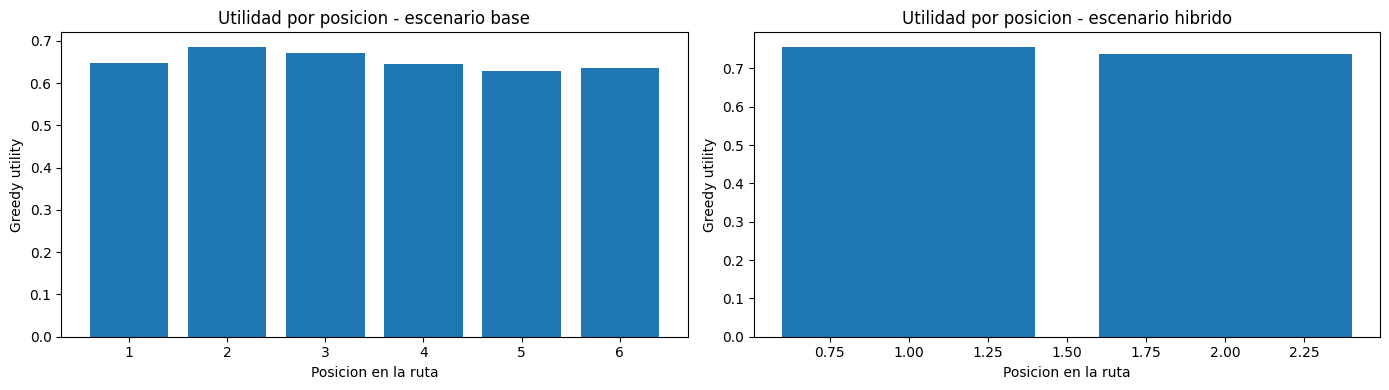

In [12]:
# ==============================
# 9. Comparacion simple entre escenarios
# ==============================

comparativa = pd.DataFrame([
    {'escenario': 'greedy_base', **summary_1},
    {'escenario': 'greedy_hibrido_simulado', **summary_2}
])

display(comparativa)

# Visualizamos la utilidad de los POIs elegidos en cada escenario.
if not route_1.empty or not route_2.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    if not route_1.empty:
        axes[0].bar(route_1['route_position'], route_1['greedy_utility'])
        axes[0].set_title('Utilidad por posicion - escenario base')
        axes[0].set_xlabel('Posicion en la ruta')
        axes[0].set_ylabel('Greedy utility')

    if not route_2.empty:
        axes[1].bar(route_2['route_position'], route_2['greedy_utility'])
        axes[1].set_title('Utilidad por posicion - escenario hibrido')
        axes[1].set_xlabel('Posicion en la ruta')
        axes[1].set_ylabel('Greedy utility')

    plt.tight_layout()
    plt.show()


## 10. Limitaciones

Aunque esta solucion es adecuada para la fase actual del TFM, conviene dejar claras sus limitaciones:

- al ser greedy, no garantiza el optimo global
- la calidad de la ruta depende de los pesos elegidos en la utilidad compuesta
- `cluster_geo` ayuda a ordenar espacialmente, pero no sustituye una red real de calles
- la distancia se calcula geodesicamente, no por red peatonal real
- `visit_duration` se usa como restriccion simple y no como modelo temporal sofisticado
- si los candidatos de entrada son pobres, la ruta tambien lo sera

Aun asi, para este proyecto estas limitaciones son aceptables porque el objetivo ahora es construir una base explicable y facil de integrar.

## 11. Relacion con el futuro sistema hibrido final

Esta fase **ya es parte del nucleo del sistema hibrido**, pero todavia no representa la integracion final completa.

La situacion tecnica es la siguiente:

- el recomendador TF-IDF ya puede aportar candidatos semanticamente relevantes
- el ranking adicional ya concluyo que `score` es suficiente como senal principal de ranking
- el clustering geografico ya aporta una senal espacial reutilizable
- este notebook aporta la logica secuencial para transformar candidatos en una ruta viable

Por tanto, el sistema hibrido final quedaria conceptualmente compuesto por dos capas:

1. **Capa de seleccion de candidatos**
   - filtros del usuario
   - TF-IDF / similitud
   - ranking por `score`

2. **Capa de construccion de ruta**
   - algoritmo greedy con restricciones
   - control de distancia, tiempo y numero de POIs
   - uso opcional de `cluster_geo`

En consecuencia, este notebook debe entenderse como una **fase puente muy cercana al sistema hibrido final**:

- no es solo una prueba aislada previa
- pero tampoco cierra por si sola toda la integracion operacional del sistema

El siguiente paso natural sera conectar esta logica con una entrada real de candidatos procedente del modulo de contenido y, despues, trasladarla al backend para que frontend y API consuman la misma estrategia.